Sources: 
- [GitHub - 5agado/data-science-learning](https://github.com/5agado/data-science-learning/blob/ee94c06cbb0fe558c40483bbfc8ef4e95db1413f/graphics/heartbeat/heartbeat_utils.py) adapted from [stackoverflow](http://stackoverflow.com/questions/4387878/simulator-of-realistic-ecg-signal-from-rr-data-for-matlab-or-python/33737898#33737898)

In [5]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import pylab

In [2]:
def get_single_heartbeat(nb_rest_samples: int):
    """
    :param nb_rest_samples: number of zeroed samples to add after the "pqrst" signal
    :return:
    """

    # The "Daubechies" wavelet is a rough approximation to a real, single, heart beat ("pqrst") signal
    pqrst = signal.daub(10)

    # Add the gap after the pqrst when the heart is resting.
    zero_array = np.zeros(nb_rest_samples, dtype=float)
    pqrst_full = np.concatenate([pqrst, zero_array])

    return pqrst_full


def get_simulated_heartbeat(bpm: int, capture_length: int, rest_factor: int = 1000):
    """
    :param bpm: beats per minute rate
    :param capture_length: simulated period of time in seconds that the ecg is captured in
    :param rest_factor
    :return:
    """

    # Calculate the number of beats in capture time period
    nb_heart_beats = int(capture_length * (bpm/60))

    hb = get_single_heartbeat(int(rest_factor/bpm))

    # Concatenate together the number of heart beats needed
    ecg_template = np.tile(hb, nb_heart_beats)

    # Add gaussian noise
    noise = np.random.normal(0, 0.01, len(ecg_template))
    ecg_template_noisy = noise + ecg_template

    return ecg_template_noisy


def simulate_heartbeat(bpm_series: list, capture_length: int = 10):
    simulations = [get_simulated_heartbeat(bpm, capture_length) for bpm in bpm_series]

    return np.concatenate(simulations)


def load_test_data(data_path):
    test_data = pd.read_csv(data_path, parse_dates=True)
    test_data.fillna(value=test_data['value'].mean(), inplace=True)
    return test_data

In [7]:
simulated_HRs = simulate_heartbeat([133, 180], capture_length=1)
len(simulated_HRs)

129

In [8]:
simulated_HRs

array([ 2.36843270e-02,  1.91974888e-01,  5.35766310e-01,  6.91861473e-01,
        2.79626990e-01, -2.55196793e-01, -1.94278905e-01,  1.18147786e-01,
        9.68364550e-02, -8.30749445e-02, -1.76380483e-02,  3.39761183e-02,
       -1.02811192e-02, -1.34559010e-02,  1.09667272e-02,  1.14364437e-02,
        1.15075867e-03, -1.18089200e-02, -1.49010410e-02, -1.56590011e-02,
        1.47677496e-03,  1.22904126e-03,  5.03836570e-03,  2.26197152e-03,
        1.93431029e-03, -1.10093304e-02, -2.12927790e-04,  3.90928815e-02,
        1.73430734e-01,  5.37873158e-01,  6.87337900e-01,  2.77866072e-01,
       -2.43498078e-01, -1.90179798e-01,  1.28194163e-01,  8.95570305e-02,
       -6.74756677e-02, -4.46819216e-02,  2.87270964e-02,  1.67326028e-02,
       -1.13162034e-02,  4.82021112e-04, -2.27442229e-02,  5.32971849e-03,
        1.46256643e-02, -1.04619492e-02, -1.22891046e-02,  2.59397537e-03,
       -2.09140743e-02,  1.03636325e-02,  1.33818151e-03, -9.79801823e-03,
        2.74032035e-03, -

In [10]:
simulated_HRs[1]

0.19197488817302905

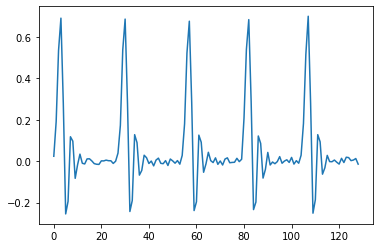

In [9]:
# Plot the sampled ecg signal
pylab.plot(simulated_HRs)
# pylab.xlabel('Sample number')
# pylab.ylabel('bit value')
# pylab.title('%d bpm ECG signal with gaussian noise sampled at %d Hz' %(bpm, sampling_rate) )
pylab.show()

In [13]:
# Simulate an ADC by sampling the noisy ecg template to produce the values
# Might be worth checking nyquist here 
# e.g. sampling rate >= (2 * template sampling rate)
sampling_rate = 50.0
num_samples = sampling_rate * 10
ecg_sampled = signal.resample(simulated_HRs, num_samples)

# Scale the normalised amplitude of the sampled ecg to whatever the ADC 
# bit resolution is
# note: check if this is correct: not sure if there should be negative bit values. 
adc_bit_resolution = 1024
ecg =  adc_bit_resolution * ecg_sampled

# Plot the sampled ecg signal
pylab.plot(ecg)
pylab.xlabel('Sample number')
pylab.ylabel('bit value')
pylab.title('%d bpm ECG signal with gaussian noise sampled at %d Hz' %(bpm, sampling_rate) )
pylab.show()

# print('saving ecg values to file')
# numpy.savetxt("ecg_values.csv", ecg, delimiter=",")
# print('Done')

TypeError: 'float' object cannot be interpreted as an integer

Simulating heart ecg


<ipython-input-7-75d3400454b1>:9: DeprecationWarning: Please use `daub` from the `scipy.signal` namespace, the `scipy.signal.wavelets` namespace is deprecated.
  pqrst = signal.wavelets.daub(10)


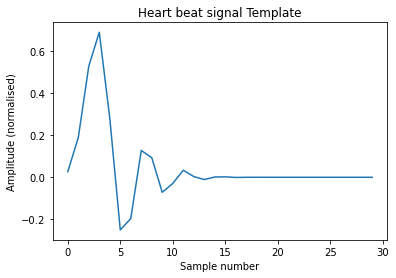

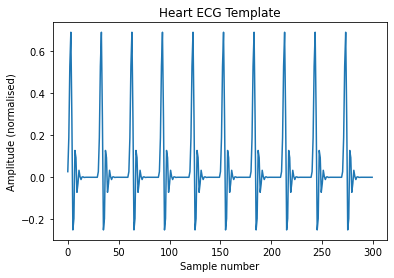

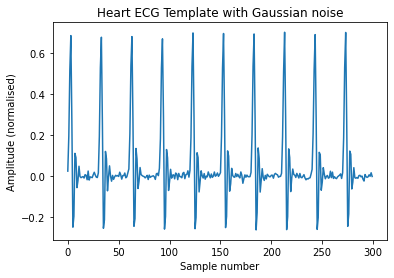

TypeError: 'float' object cannot be interpreted as an integer

In [7]:
import pylab
import scipy.signal as signal
import numpy 

print('Simulating heart ecg')

# The "Daubechies" wavelet is a rough approximation to a real,
# single, heart beat ("pqrst") signal
pqrst = signal.wavelets.daub(10)

# Add the gap after the pqrst when the heart is resting. 
samples_rest = 10
zero_array = numpy.zeros(samples_rest, dtype=float)
pqrst_full = numpy.concatenate([pqrst,zero_array])

# Plot the heart signal template
pylab.plot(pqrst_full)
pylab.xlabel('Sample number')
pylab.ylabel('Amplitude (normalised)')
pylab.title('Heart beat signal Template')
pylab.show()

# Simulated Beats per minute rate
# For a health, athletic, person, 60 is resting, 180 is intensive exercising
bpm = 60
bps = bpm / 60

# Simumated period of time in seconds that the ecg is captured in
capture_length = 10

# Caculate the number of beats in capture time period 
# Round the number to simplify things
num_heart_beats = int(capture_length * bps)

# Concatonate together the number of heart beats needed
ecg_template = numpy.tile(pqrst_full , num_heart_beats)

# Plot the heart ECG template
pylab.plot(ecg_template)
pylab.xlabel('Sample number')
pylab.ylabel('Amplitude (normalised)')
pylab.title('Heart ECG Template')
pylab.show()

# Add random (gaussian distributed) noise 
noise = numpy.random.normal(0, 0.01, len(ecg_template))
ecg_template_noisy = noise + ecg_template

# Plot the noisy heart ECG template
pylab.plot(ecg_template_noisy)
pylab.xlabel('Sample number')
pylab.ylabel('Amplitude (normalised)')
pylab.title('Heart ECG Template with Gaussian noise')
pylab.show()


# Simulate an ADC by sampling the noisy ecg template to produce the values
# Might be worth checking nyquist here 
# e.g. sampling rate >= (2 * template sampling rate)
sampling_rate = 50.0
num_samples = sampling_rate * capture_length
ecg_sampled = signal.resample(ecg_template_noisy, num_samples)

# Scale the normalised amplitude of the sampled ecg to whatever the ADC 
# bit resolution is
# note: check if this is correct: not sure if there should be negative bit values. 
adc_bit_resolution = 1024
ecg =  adc_bit_resolution * ecg_sampled

# Plot the sampled ecg signal
pylab.plot(ecg)
pylab.xlabel('Sample number')
pylab.ylabel('bit value')
pylab.title('%d bpm ECG signal with gaussian noise sampled at %d Hz' %(bpm, sampling_rate) )
pylab.show()

# print('saving ecg values to file')
# numpy.savetxt("ecg_values.csv", ecg, delimiter=",")
# print('Done')